# Análise exploratória da PNS 2019 em quatro grupos

1. pessoas com diagnóstico autorreferido e PHQ-9 ≥ 10;
2. pessoas com diagnóstico autorreferido e PHQ-9 < 10;
3. pessoas sem diagnóstico autorreferido e PHQ-9 ≥ 10;
4. pessoas sem diagnóstico autorreferido e PHQ-9 < 10.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from IPython.display import display

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_rows", 300)
pd.set_option("display.float_format", lambda valor: f"{valor:,.3f}")

In [2]:
PASTA = Path.cwd()
arquivo_2019 = PASTA / "pns2019.csv"

## Todas as variáveis selecionadas

In [3]:
variaveis_analise = [
    # Técnica e desfecho
    "V0025A", "V00291", "V0024", "UPA_PNS", "Q092",
    "N010", "N011", "N012", "N013", "N014",
    "N015", "N016", "N017", "N018",

    # Demográficas e territoriais
    "V0001", "V0026",
    "C006", "C008", "C009", "C01001", "C011",

    # Socioeconômicas e trabalho
    "VDD004A", "VDF003", "VDF004",
    "VDE001", "VDE002",
    "E001", "E017", "E033",

    # Domicílio
    "A01401", "A01501", "A016010", "A01901",

    # Apoio social
    "M01401", "M01501",
    "M01601", "M01701", "M01801", "M01901",

    # Acesso à saúde
    "B001", "B003",
    "I00102", "J001", "J037",

    # Alimentação
    "P00601", "P00602", "P00603", "P00604",
    "P00605", "P00607", "P00608",
    "P00609", "P00610", "P00611", "P00612",
    "P00613", "P00614", "P00615", "P00616",
    "P00617", "P00618",

    # Álcool, atividade física e tabaco
    "P029",
    "P034", "P035", "P036", "P03701",
    "P050",

    # Violência psicológica
    "V00201", "V00202", "V00203",
    "V00204", "V00205",

    # Violência física
    "V01401", "V01402", "V01403",
    "V01404", "V01405",

    # Violência sexual
    "V02701", "V02702",

    # Saúde geral e comorbidades
    "N001",
    "Q00201", "Q03001", "Q060",
    "Q06307", "Q068", "Q074",
    "Q079", "Q084", "Q088",
    "Q11006",
]


In [4]:
grupos_originais = {
    "Itens do PHQ-9": [
        "N010", "N011", "N012", "N013", "N014",
        "N015", "N016", "N017", "N018",
    ],
    "Demográficas e territoriais": [
        "V0001", "V0026", "C006", "C008",
        "C009", "C01001", "C011",
    ],
    "Socioeconômicas e trabalho": [
        "VDD004A", "VDF003", "VDF004",
        "VDE001", "VDE002", "E001", "E017", "E033",
    ],
    "Domicílio": [
        "A01401", "A01501", "A016010", "A01901",
    ],
    "Apoio social": [
        "M01401", "M01501", "M01601",
        "M01701", "M01801", "M01901",
    ],
    "Acesso à saúde": [
        "B001", "B003", "I00102", "J001", "J037",
    ],
    "Alimentação": [
        "P00601", "P00602", "P00603", "P00604",
        "P00605", "P00607", "P00608",
        "P00609", "P00610", "P00611", "P00612",
        "P00613", "P00614", "P00615", "P00616",
        "P00617", "P00618",
    ],
    "Álcool, atividade física e tabaco": [
        "P029", "P034", "P035", "P036", "P03701", "P050",
    ],
    "Violência psicológica": [
        "V00201", "V00202", "V00203", "V00204", "V00205",
    ],
    "Violência física": [
        "V01401", "V01402", "V01403", "V01404", "V01405",
    ],
    "Violência sexual": [
        "V02701", "V02702",
    ],
    "Saúde geral e comorbidades": [
        "N001", "Q00201", "Q03001", "Q060", "Q06307",
        "Q068", "Q074", "Q079", "Q084", "Q088", "Q11006",
    ],
}

## Conferir 


In [5]:
cabecalho = pd.read_csv(
    arquivo_2019,
    sep=",",
    nrows=0,
)

cabecalho.columns = cabecalho.columns.str.strip()

variaveis_disponiveis = [
    coluna
    for coluna in variaveis_analise
    if coluna in cabecalho.columns
]

variaveis_ausentes = [
    coluna
    for coluna in variaveis_analise
    if coluna not in cabecalho.columns
]

print("Variáveis disponíveis:", len(variaveis_disponiveis))
print("Variáveis ausentes:", len(variaveis_ausentes))

if variaveis_ausentes:
    print("\nVariáveis não encontradas no CSV:")
    print(variaveis_ausentes)

obrigatorias = ["V0025A", "C008", "V00291", "Q092"]
faltantes_obrigatorias = [
    coluna
    for coluna in obrigatorias
    if coluna not in cabecalho.columns
]

if faltantes_obrigatorias:
    raise ValueError(
        f"Colunas obrigatórias ausentes: {faltantes_obrigatorias}"
    )

Variáveis disponíveis: 90
Variáveis ausentes: 0


In [6]:
dados = pd.read_csv(
    arquivo_2019,
    sep=",",
    usecols=variaveis_disponiveis,
    low_memory=False,
)

print("Formato inicial:", dados.shape)
display(dados.head())

Formato inicial: (293726, 90)


,V0001,V0024,UPA_PNS,V0026,V0025A,A01401,A01501,A016010,A01901,B001,B003,C006,C008,C009,C01001,C011,E001,E017,E033,I00102,J001,J037,M01401,M01501,M01601,M01701,M01801,M01901,N001,N010,N011,N012,N013,N014,N015,N016,N017,N018,P00601,P00602,P00603,P00604,P00605,P00607,P00608,P00609,P00610,P00611,P00612,P00613,P00614,P00615,P00616,P00617,P00618,P029,P034,P035,P03701,P036,P050,Q00201,Q03001,Q060,Q06307,Q068,Q074,Q079,Q084,Q088,Q092,Q11006,V00201,V00202,V00203,V00204,V00205,V01401,V01402,V01403,V01404,V01405,V02701,V02702,V00291,VDD004A,VDE001,VDE002,VDF003,VDF004
0,11,1110011,110000016,1,1.000,2.000,4.000,1.000,1.000,1.000,4.000,2.000,55.000,1.000,1.000,1.000,1.000,40.000,35.000,2.000,3.000,2.000,3.000,0.000,6.000,6.000,6.000,2.000,3.000,4.000,2.000,2.000,1.000,1.000,1.000,2.000,1.000,1.000,1.000,1.000,1.000,1.000,2.000,1.000,2.000,1.000,1.000,2.000,1.000,2.000,1.000,1.000,2.000,2.000,2.000,5.000,1.000,1.000,0.000,1.000,3.000,1.000,2.000,1.000,NaN,2.000,2.000,1.000,1.000,2.000,1.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,368.875,2.000,1.000,1.000,350.000,2.000
1,11,1110011,110000016,1,0.000,2.000,4.000,1.000,1.000,1.000,4.000,1.000,69.000,4.000,1.000,1.000,2.000,NaN,35.000,2.000,3.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,2.000,NaN,350.000,2.000
2,11,1110011,110000016,1,0.000,2.000,4.000,1.000,1.000,1.000,4.000,1.000,31.000,2.000,2.000,4.000,1.000,36.000,28.000,2.000,3.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000,1.000,1.000,350.000,2.000
3,11,1110011,110000016,1,9.000,2.000,4.000,1.000,1.000,1.000,4.000,1.000,9.000,2.000,NaN,NaN,NaN,NaN,NaN,2.000,2.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,350.000,2.000
4,11,1110011,110000016,1,9.000,2.000,4.000,1.000,1.000,1.000,4.000,2.000,6.000,4.000,NaN,NaN,NaN,NaN,NaN,2.000,2.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,350.000,2.000


In [7]:
for coluna in dados.columns:
    dados[coluna] = pd.to_numeric(
        dados[coluna],
        errors="coerce",
    )

`Q092 = 1` representa diagnóstico autorreferido e `Q092 = 2` representa ausência de diagnóstico autorreferido.

In [8]:
dados = dados[
    (dados["V0025A"] == 1)
    & (dados["C008"] >= 18)
].copy()

dados["Diagnóstico de depressão"] = dados["Q092"].map({
    1: "Com diagnóstico",
    2: "Sem diagnóstico",
})

dados["Diagnóstico binário"] = dados["Q092"].map({
    1: 1,
    2: 0,
})

dados = dados[
    dados["Diagnóstico de depressão"].notna()
].copy()

dados["Peso"] = dados["V00291"].where(
    dados["V00291"] > 0
)

print("Adultos com resposta válida para Q092:", len(dados))

display(
    dados["Diagnóstico de depressão"]
    .value_counts()
    .rename("Quantidade")
)

Adultos com resposta válida para Q092: 88531


Diagnóstico de depressão
Sem diagnóstico    80289
Com diagnóstico     8242
Name: Quantidade, dtype: int64

Codificação identificada para o PHQ-9: 1 a 4, convertida para 0 a 3
Adultos com diagnóstico válido, PHQ-9 completo e peso válido: 88531
Adultos com diagnóstico válido, mas sem classificação nos quatro grupos: 0


,Grupo diagnóstico e PHQ-9,Participantes,População_estimada,PHQ9_médio,PHQ9_mediano,Proporção ponderada da população válida (%)
0,Com diagnóstico e PHQ-9 ≥ 10,3140,"6,351,690.110",15.800,15.000,3.990
1,Com diagnóstico e PHQ-9 < 10,5102,"9,940,982.830",4.100,4.000,6.250
2,Sem diagnóstico e PHQ-9 ≥ 10,6112,"10,884,400.380",13.920,13.000,6.840
3,Sem diagnóstico e PHQ-9 < 10,74177,"131,994,237.690",1.930,1.000,82.930


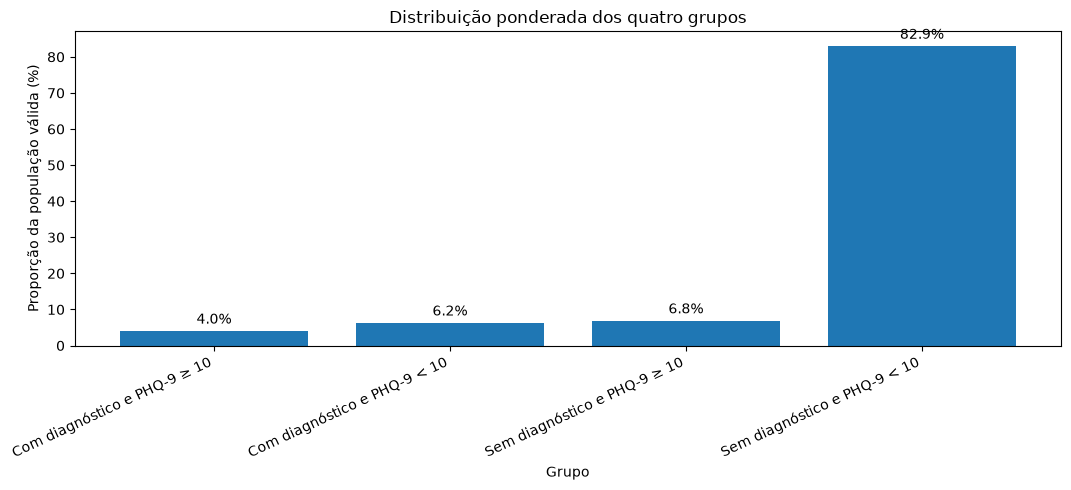

In [9]:
itens_phq9 = [
    "N010", "N011", "N012",
    "N013", "N014", "N015",
    "N016", "N017", "N018",
]

itens_ausentes = [
    item
    for item in itens_phq9
    if item not in dados.columns
]

if itens_ausentes:
    raise ValueError(
        "Os seguintes itens do PHQ-9 não foram carregados: "
        + ", ".join(itens_ausentes)
    )

# Verifica as duas codificações possíveis.
validos_1_a_4 = (
    dados[itens_phq9]
    .isin([1, 2, 3, 4])
    .all(axis=1)
)

validos_0_a_3 = (
    dados[itens_phq9]
    .isin([0, 1, 2, 3])
    .all(axis=1)
)

if validos_1_a_4.sum() >= validos_0_a_3.sum():
    mascara_phq9_completo = validos_1_a_4
    pontuacao_phq9 = dados[itens_phq9] - 1
    codificacao_phq9 = "1 a 4, convertida para 0 a 3"
else:
    mascara_phq9_completo = validos_0_a_3
    pontuacao_phq9 = dados[itens_phq9].copy()
    codificacao_phq9 = "0 a 3"

dados["PHQ-9 completo"] = mascara_phq9_completo

dados["Escore PHQ-9"] = np.nan

dados.loc[
    mascara_phq9_completo,
    "Escore PHQ-9",
] = (
    pontuacao_phq9.loc[
        mascara_phq9_completo,
        itens_phq9,
    ]
    .sum(axis=1)
)

dados["Faixa PHQ-9"] = pd.Series(
    pd.NA,
    index=dados.index,
    dtype="object",
)

dados.loc[
    dados["Escore PHQ-9"].notna()
    & (dados["Escore PHQ-9"] >= 10),
    "Faixa PHQ-9",
] = "PHQ-9 ≥ 10"

dados.loc[
    dados["Escore PHQ-9"].notna()
    & (dados["Escore PHQ-9"] < 10),
    "Faixa PHQ-9",
] = "PHQ-9 < 10"

ordem_quatro_grupos = [
    "Com diagnóstico e PHQ-9 ≥ 10",
    "Com diagnóstico e PHQ-9 < 10",
    "Sem diagnóstico e PHQ-9 ≥ 10",
    "Sem diagnóstico e PHQ-9 < 10",
]

dados["Grupo diagnóstico e PHQ-9"] = pd.Series(
    pd.NA,
    index=dados.index,
    dtype="object",
)

dados.loc[
    (dados["Diagnóstico binário"] == 1)
    & (dados["Escore PHQ-9"] >= 10),
    "Grupo diagnóstico e PHQ-9",
] = "Com diagnóstico e PHQ-9 ≥ 10"

dados.loc[
    (dados["Diagnóstico binário"] == 1)
    & (dados["Escore PHQ-9"] < 10),
    "Grupo diagnóstico e PHQ-9",
] = "Com diagnóstico e PHQ-9 < 10"

dados.loc[
    (dados["Diagnóstico binário"] == 0)
    & (dados["Escore PHQ-9"] >= 10),
    "Grupo diagnóstico e PHQ-9",
] = "Sem diagnóstico e PHQ-9 ≥ 10"

dados.loc[
    (dados["Diagnóstico binário"] == 0)
    & (dados["Escore PHQ-9"] < 10),
    "Grupo diagnóstico e PHQ-9",
] = "Sem diagnóstico e PHQ-9 < 10"

dados["Grupo diagnóstico e PHQ-9"] = pd.Categorical(
    dados["Grupo diagnóstico e PHQ-9"],
    categories=ordem_quatro_grupos,
    ordered=True,
)

base_quatro_grupos = dados.dropna(
    subset=[
        "Grupo diagnóstico e PHQ-9",
        "Peso",
    ]
).copy()

base_quatro_grupos = base_quatro_grupos[
    base_quatro_grupos["Peso"] > 0
].copy()

resumo_geral_quatro_grupos = (
    base_quatro_grupos
    .groupby(
        "Grupo diagnóstico e PHQ-9",
        observed=False,
    )
    .agg(
        Participantes=(
            "Grupo diagnóstico e PHQ-9",
            "size",
        ),
        População_estimada=(
            "Peso",
            "sum",
        ),
        PHQ9_médio=(
            "Escore PHQ-9",
            "mean",
        ),
        PHQ9_mediano=(
            "Escore PHQ-9",
            "median",
        ),
    )
    .reset_index()
)

resumo_geral_quatro_grupos[
    "Proporção ponderada da população válida (%)"
] = (
    resumo_geral_quatro_grupos["População_estimada"]
    / resumo_geral_quatro_grupos["População_estimada"].sum()
    * 100
)

print("Codificação identificada para o PHQ-9:", codificacao_phq9)

print(
    "Adultos com diagnóstico válido, PHQ-9 completo e peso válido:",
    len(base_quatro_grupos),
)

print(
    "Adultos com diagnóstico válido, mas sem classificação "
    "nos quatro grupos:",
    int(dados["Grupo diagnóstico e PHQ-9"].isna().sum()),
)

display(resumo_geral_quatro_grupos.round(2))

plt.figure(figsize=(11, 5))

barras = plt.bar(
    resumo_geral_quatro_grupos[
        "Grupo diagnóstico e PHQ-9"
    ].astype(str),
    resumo_geral_quatro_grupos[
        "Proporção ponderada da população válida (%)"
    ],
)

plt.title("Distribuição ponderada dos quatro grupos")
plt.xlabel("Grupo")
plt.ylabel("Proporção da população válida (%)")
plt.xticks(rotation=25, ha="right")
plt.bar_label(barras, fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()


In [10]:
def sim_nao(serie):
    return serie.map({
        1: "Sim",
        2: "Não",
    })


def codigos_como_texto(serie):
    resultado = pd.Series(
        pd.NA,
        index=serie.index,
        dtype="object",
    )

    validos = serie.notna()

    resultado.loc[validos] = (
        "Código "
        + serie.loc[validos].astype(int).astype(str)
    )

    return resultado


variaveis_preparadas = {}


def registrar(nome, bloco, origem):
    variaveis_preparadas[nome] = {
        "Bloco": bloco,
        "Origem": origem,
    }

## Demográficas e territoriais

In [11]:
if "C006" in dados.columns:
    dados["Sexo"] = dados["C006"].map({
        1: "Homem",
        2: "Mulher",
    })
    registrar("Sexo", "Demográficas e territoriais", "C006")

if "C008" in dados.columns:
    dados["Faixa etária"] = pd.cut(
        dados["C008"],
        bins=[17, 29, 39, 49, 59, 69, np.inf],
        labels=[
            "18–29", "30–39", "40–49",
            "50–59", "60–69", "70+",
        ],
    )
    registrar("Faixa etária", "Demográficas e territoriais", "C008")

if "C009" in dados.columns:
    dados["Raça/cor"] = dados["C009"].map({
        1: "Branca",
        2: "Preta",
        3: "Amarela",
        4: "Parda",
        5: "Indígena",
    })
    registrar("Raça/cor", "Demográficas e territoriais", "C009")

if "C010" in dados.columns:
    dados["Vive com cônjuge"] = sim_nao(dados["C010"])
    registrar("Vive com cônjuge", "Demográficas e territoriais", "C010")

if "C011" in dados.columns:
    dados["Estado civil"] = dados["C011"].map({
        1: "Casada(o)",
        2: "Divorciada(o) ou separada(o)",
        3: "Viúva(o)",
        4: "Solteira(o)",
    })
    registrar("Estado civil", "Demográficas e territoriais", "C011")

if "Y008" in dados.columns:
    dados["Orientação sexual — códigos"] = codigos_como_texto(
        dados["Y008"]
    )
    registrar(
        "Orientação sexual — códigos",
        "Demográficas e territoriais",
        "Y008",
    )

if "V0026" in dados.columns:
    dados["Área"] = dados["V0026"].map({
        1: "Urbana",
        2: "Rural",
    })
    registrar("Área", "Demográficas e territoriais", "V0026")

if "V0001" in dados.columns:
    nomes_uf = {
        11: "Rondônia", 12: "Acre", 13: "Amazonas",
        14: "Roraima", 15: "Pará", 16: "Amapá", 17: "Tocantins",
        21: "Maranhão", 22: "Piauí", 23: "Ceará",
        24: "Rio Grande do Norte", 25: "Paraíba", 26: "Pernambuco",
        27: "Alagoas", 28: "Sergipe", 29: "Bahia",
        31: "Minas Gerais", 32: "Espírito Santo",
        33: "Rio de Janeiro", 35: "São Paulo",
        41: "Paraná", 42: "Santa Catarina", 43: "Rio Grande do Sul",
        50: "Mato Grosso do Sul", 51: "Mato Grosso",
        52: "Goiás", 53: "Distrito Federal",
    }

    dados["UF"] = dados["V0001"].map(nomes_uf)

    dados["Região"] = pd.Series(
        pd.NA,
        index=dados.index,
        dtype="object",
    )

    dados.loc[dados["V0001"].between(11, 17), "Região"] = "Norte"
    dados.loc[dados["V0001"].between(21, 29), "Região"] = "Nordeste"
    dados.loc[dados["V0001"].between(31, 35), "Região"] = "Sudeste"
    dados.loc[dados["V0001"].between(41, 43), "Região"] = "Sul"
    dados.loc[dados["V0001"].between(50, 53), "Região"] = "Centro-Oeste"

    registrar("UF", "Demográficas e territoriais", "V0001")
    registrar("Região", "Demográficas e territoriais", "V0001")

## Socioeconômicas e trabalho

In [12]:
if "VDD004A" in dados.columns:
    dados["Escolaridade"] = dados["VDD004A"].map({
        1: "Sem instrução / Fundamental incompleto",
        2: "Sem instrução / Fundamental incompleto",
        3: "Fundamental completo / Médio incompleto",
        4: "Fundamental completo / Médio incompleto",
        5: "Médio completo",
        6: "Superior",
        7: "Superior",
    })
    registrar("Escolaridade", "Socioeconômicas e trabalho", "VDD004A")

if "VDF003" in dados.columns:
    dados["Renda per capita"] = dados["VDF003"].where(
        dados["VDF003"] >= 0
    )

    filtro = dados["Renda per capita"].notna()
    postos = dados.loc[filtro, "Renda per capita"].rank(method="first")

    dados["Quintil de renda"] = pd.Series(
        pd.NA,
        index=dados.index,
        dtype="object",
    )

    dados.loc[filtro, "Quintil de renda"] = pd.qcut(
        postos,
        q=5,
        labels=[
            "Q1 — menor renda", "Q2", "Q3", "Q4", "Q5 — maior renda",
        ],
    ).astype(str)

    registrar("Quintil de renda", "Socioeconômicas e trabalho", "VDF003")

if "VDF004" in dados.columns:
    dados["Faixa de renda — códigos"] = codigos_como_texto(
        dados["VDF004"]
    )
    registrar(
        "Faixa de renda — códigos",
        "Socioeconômicas e trabalho",
        "VDF004",
    )

if "VDE001" in dados.columns:
    dados["Força de trabalho"] = dados["VDE001"].map({
        1: "Na força de trabalho",
        2: "Fora da força de trabalho",
    })
    registrar("Força de trabalho", "Socioeconômicas e trabalho", "VDE001")

if "VDE002" in dados.columns:
    dados["Condição de ocupação"] = dados["VDE002"].map({
        1: "Ocupada",
        2: "Desocupada",
    })
    registrar(
        "Condição de ocupação",
        "Socioeconômicas e trabalho",
        "VDE002",
    )

if "E001" in dados.columns:
    dados["Trabalhou em atividade remunerada"] = sim_nao(dados["E001"])
    registrar(
        "Trabalhou em atividade remunerada",
        "Socioeconômicas e trabalho",
        "E001",
    )

if "E017" in dados.columns:
    dados["Faixa de horas trabalhadas"] = pd.cut(
        dados["E017"],
        bins=[-0.1, 19, 39, 44, 60, np.inf],
        labels=[
            "Até 19 h", "20–39 h", "40–44 h",
            "45–60 h", "Mais de 60 h",
        ],
    )
    registrar(
        "Faixa de horas trabalhadas",
        "Socioeconômicas e trabalho",
        "E017",
    )

if "E033" in dados.columns:
    dados["Faixa de horas domésticas"] = pd.cut(
        dados["E033"],
        bins=[-0.1, 4, 9, 19, 39, np.inf],
        labels=[
            "Até 4 h", "5–9 h", "10–19 h",
            "20–39 h", "40 h ou mais",
        ],
    )
    registrar(
        "Faixa de horas domésticas",
        "Socioeconômicas e trabalho",
        "E033",
    )

## Domicílio

In [13]:
if "A01401" in dados.columns:
    dados["Quantidade de banheiros"] = pd.cut(
        dados["A01401"],
        bins=[-0.1, 0, 1, 2, np.inf],
        labels=["Nenhum", "1 banheiro", "2 banheiros", "3 ou mais"],
    )
    registrar("Quantidade de banheiros", "Domicílio", "A01401")

if "A01501" in dados.columns:
    dados["Esgoto — códigos"] = codigos_como_texto(dados["A01501"])
    registrar("Esgoto — códigos", "Domicílio", "A01501")

if "A016010" in dados.columns:
    dados["Destino do lixo — códigos"] = codigos_como_texto(
        dados["A016010"]
    )
    registrar("Destino do lixo — códigos", "Domicílio", "A016010")

if "A01901" in dados.columns:
    dados["Internet no domicílio"] = sim_nao(dados["A01901"])
    registrar("Internet no domicílio", "Domicílio", "A01901")

## Apoio social

In [14]:
for original, nova in {
    "M01401": "Faixa de familiares com quem pode contar",
    "M01501": "Faixa de amigos com quem pode contar",
}.items():
    if original in dados.columns:
        dados[nova] = pd.cut(
            dados[original],
            bins=[-0.1, 0, 1, 2, 4, np.inf],
            labels=[
                "Nenhum", "1 pessoa", "2 pessoas",
                "3–4 pessoas", "5 ou mais",
            ],
        )
        registrar(nova, "Apoio social", original)

for original, nova in {
    "M01601": "Atividade em grupo — códigos",
    "M01701": "Participação comunitária — códigos",
    "M01801": "Trabalho voluntário — códigos",
    "M01901": "Atividade religiosa — códigos",
}.items():
    if original in dados.columns:
        dados[nova] = codigos_como_texto(dados[original])
        registrar(nova, "Apoio social", original)

## Acesso geral aos serviços de saúde

In [15]:
if "B001" in dados.columns:
    dados["Cadastro na Saúde da Família — códigos"] = codigos_como_texto(
        dados["B001"]
    )
    registrar(
        "Cadastro na Saúde da Família — códigos",
        "Acesso à saúde",
        "B001",
    )

if "B003" in dados.columns:
    dados["Visita da Saúde da Família — códigos"] = codigos_como_texto(
        dados["B003"]
    )
    registrar(
        "Visita da Saúde da Família — códigos",
        "Acesso à saúde",
        "B003",
    )

for original, nova in {
    "I00102": "Possui plano de saúde",
    "J001": "Procura o mesmo serviço de saúde",
    "J037": "Internação nos últimos 12 meses",
}.items():
    if original in dados.columns:
        dados[nova] = sim_nao(dados[original])
        registrar(nova, "Acesso à saúde", original)

## Alimentação

In [16]:
alimentos_disponiveis = [
    coluna
    for coluna in grupos_originais["Alimentação"]
    if coluna in dados.columns
]

for coluna in alimentos_disponiveis:
    nome = f"{coluna} — consumo no dia anterior"
    dados[nome] = dados[coluna].map({1: "Sim", 2: "Não"})
    registrar(nome, "Alimentação", coluna)

alimentos_in_natura = [
    coluna
    for coluna in [
        "P00601", "P00602", "P00603", "P00604", "P00605",
        "P00607", "P00608", "P00609", "P00610", "P00611",
        "P00612", "P00613",
    ]
    if coluna in dados.columns
]

ultraprocessados = [
    coluna
    for coluna in [
        "P00614", "P00615", "P00616", "P00617", "P00618",
    ]
    if coluna in dados.columns
]

if alimentos_in_natura:
    dados["Quantidade de grupos in natura"] = (
        dados[alimentos_in_natura] == 1
    ).sum(axis=1)

    dados["Faixa de alimentos in natura"] = pd.cut(
        dados["Quantidade de grupos in natura"],
        bins=[-0.1, 3, 6, 9, np.inf],
        labels=["0–3 grupos", "4–6 grupos", "7–9 grupos", "10 ou mais"],
    )
    registrar("Faixa de alimentos in natura", "Alimentação", "Indicador derivado")

if ultraprocessados:
    dados["Quantidade de ultraprocessados"] = (
        dados[ultraprocessados] == 1
    ).sum(axis=1)

    dados["Faixa de ultraprocessados"] = pd.cut(
        dados["Quantidade de ultraprocessados"],
        bins=[-0.1, 0, 1, 2, np.inf],
        labels=["Nenhum", "1 grupo", "2 grupos", "3 ou mais"],
    )
    registrar("Faixa de ultraprocessados", "Alimentação", "Indicador derivado")

## Álcool, atividade física e tabaco

In [17]:
if "P029" in dados.columns:
    dados["Faixa de doses de álcool"] = pd.cut(
        dados["P029"],
        bins=[-0.1, 0, 2, 4, 7, np.inf],
        labels=["Nenhuma", "1–2 doses", "3–4 doses", "5–7 doses", "8 ou mais"],
    )
    registrar(
        "Faixa de doses de álcool",
        "Álcool, atividade física e tabaco",
        "P029",
    )

if "P034" in dados.columns:
    dados["Pratica exercício"] = sim_nao(dados["P034"])
    registrar(
        "Pratica exercício",
        "Álcool, atividade física e tabaco",
        "P034",
    )

if {"P035", "P036", "P037"}.issubset(dados.columns):
    dados["Minutos de exercício por semana"] = (
        dados["P035"]
        * (dados["P036"] * 60 + dados["P037"])
    )

    dados["Faixa de exercício semanal"] = pd.cut(
        dados["Minutos de exercício por semana"],
        bins=[-0.1, 0, 74, 149, 299, np.inf],
        labels=[
            "Nenhum", "1–74 min", "75–149 min",
            "150–299 min", "300 min ou mais",
        ],
    )
    registrar(
        "Faixa de exercício semanal",
        "Álcool, atividade física e tabaco",
        "P035/P036/P037",
    )

if "P050" in dados.columns:
    dados["Uso de tabaco — códigos"] = codigos_como_texto(dados["P050"])
    registrar(
        "Uso de tabaco — códigos",
        "Álcool, atividade física e tabaco",
        "P050",
    )

## Violência psicológica, física e sexual

In [18]:
blocos_violencia = {
    "Violência psicológica": [
        "V00201", "V00202", "V00203", "V00204", "V00205",
    ],
    "Violência física": [
        "V01401", "V01402", "V01403", "V01404", "V01405",
    ],
    "Violência sexual": [
        "V02701", "V02702",
    ],
}

for bloco, colunas in blocos_violencia.items():
    disponiveis = [
        coluna
        for coluna in colunas
        if coluna in dados.columns
    ]

    for coluna in disponiveis:
        nome = f"{coluna} — item de {bloco.lower()}"
        dados[nome] = dados[coluna].map({1: "Sim", 2: "Não"})
        registrar(nome, bloco, coluna)

    if disponiveis:
        respostas_validas = dados[disponiveis].isin([1, 2])

        indicador = np.where(
            respostas_validas.any(axis=1),
            (dados[disponiveis] == 1).any(axis=1).astype(int),
            np.nan,
        )

        dados[bloco] = pd.Series(indicador, index=dados.index).map({
            1: "Sim",
            0: "Não",
        })

        registrar(bloco, bloco, "Indicador derivado")

## Saúde geral e comorbidades

In [19]:
if "N001" in dados.columns:
    dados["Estado de saúde"] = dados["N001"].map({
        1: "Muito bom",
        2: "Bom",
        3: "Regular",
        4: "Ruim",
        5: "Muito ruim",
    })
    registrar("Estado de saúde", "Saúde geral e comorbidades", "N001")

comorbidades = {
    "Q00201": "Hipertensão",
    "Q03001": "Diabetes",
    "Q060": "Colesterol alto",
    "Q06307": "Doença do coração",
    "Q068": "AVC",
    "Q074": "Asma",
    "Q079": "Artrite ou reumatismo",
    "Q084": "Problema crônico de coluna",
    "Q088": "DORT ou doença do trabalho",
    "Q11006": "Outra doença mental",
}

comorbidades_disponiveis = []

for original, nova in comorbidades.items():
    if original in dados.columns:
        dados[nova] = dados[original].map({1: "Sim", 2: "Não"})
        registrar(nova, "Saúde geral e comorbidades", original)
        comorbidades_disponiveis.append(original)

if comorbidades_disponiveis:
    dados["Número de comorbidades selecionadas"] = (
        dados[comorbidades_disponiveis] == 1
    ).sum(axis=1)

    dados["Faixa de comorbidades"] = pd.cut(
        dados["Número de comorbidades selecionadas"],
        bins=[-0.1, 0, 1, 2, np.inf],
        labels=["Nenhuma", "1 condição", "2 condições", "3 ou mais"],
    )

    registrar(
        "Faixa de comorbidades",
        "Saúde geral e comorbidades",
        "Indicador derivado",
    )

## Inventário final das variáveis preparadas

In [20]:
inventario = pd.DataFrame([
    {
        "Variável preparada": nome,
        "Bloco": info["Bloco"],
        "Origem": info["Origem"],
    }
    for nome, info in variaveis_preparadas.items()
]).sort_values(
    ["Bloco", "Variável preparada"]
).reset_index(drop=True)

print("Quantidade de variáveis preparadas:", len(inventario))
display(inventario)

Quantidade de variáveis preparadas: 79


,Variável preparada,Bloco,Origem
0,Cadastro na Saúde da Família — códigos,Acesso à saúde,B001
1,Internação nos últimos 12 meses,Acesso à saúde,J037
2,Possui plano de saúde,Acesso à saúde,I00102
3,Procura o mesmo serviço de saúde,Acesso à saúde,J001
4,Visita da Saúde da Família — códigos,Acesso à saúde,B003
5,Faixa de alimentos in natura,Alimentação,Indicador derivado
6,Faixa de ultraprocessados,Alimentação,Indicador derivado
7,P00601 — consumo no dia anterior,Alimentação,P00601
8,P00602 — consumo no dia anterior,Alimentação,P00602
9,P00603 — consumo no dia anterior,Alimentação,P00603


In [21]:
def tabela_ponderada_categoria_grupo(variavel):
    coluna_grupo = "Grupo diagnóstico e PHQ-9"

    base = dados[
        [
            variavel,
            coluna_grupo,
            "Peso",
        ]
    ].dropna(
        subset=[
            variavel,
            coluna_grupo,
            "Peso",
        ]
    ).copy()

    base = base[base["Peso"] > 0]

    tabela = (
        base
        .groupby(
            [variavel, coluna_grupo],
            observed=False,
        )["Peso"]
        .sum()
        .unstack(fill_value=0)
        .reindex(
            columns=ordem_quatro_grupos,
            fill_value=0,
        )
    )

    return base, tabela


def analisar_variavel_quatro_grupos(variavel):
    coluna_grupo = "Grupo diagnóstico e PHQ-9"

    base, populacao = tabela_ponderada_categoria_grupo(
        variavel
    )

    contagem = pd.crosstab(
        base[variavel],
        base[coluna_grupo],
    ).reindex(
        columns=ordem_quatro_grupos,
        fill_value=0,
    )

    percentuais_amostra_dentro_grupo = (
        contagem
        .div(contagem.sum(axis=0), axis=1)
        * 100
    )

    percentuais_ponderados_dentro_grupo = (
        populacao
        .div(populacao.sum(axis=0), axis=1)
        * 100
    )


    grupos_dentro_categoria = (
        populacao
        .div(populacao.sum(axis=1), axis=0)
        * 100
    )


    distribuicao_geral = (
        populacao.sum(axis=1)
        / populacao.to_numpy().sum()
        * 100
    )

    diferencas_da_distribuicao_geral = (
        percentuais_ponderados_dentro_grupo
        .sub(distribuicao_geral, axis=0)
    )

    comparacao = (
        percentuais_ponderados_dentro_grupo
        .copy()
    )

    comparacao["Distribuição geral (%)"] = (
        distribuicao_geral
    )

    comparacao["Maior percentual entre grupos (%)"] = (
        percentuais_ponderados_dentro_grupo.max(axis=1)
    )

    comparacao["Menor percentual entre grupos (%)"] = (
        percentuais_ponderados_dentro_grupo.min(axis=1)
    )

    comparacao["Amplitude entre grupos (p.p.)"] = (
        comparacao["Maior percentual entre grupos (%)"]
        - comparacao["Menor percentual entre grupos (%)"]
    )

    comparacao["Grupo com maior percentual"] = (
        percentuais_ponderados_dentro_grupo.idxmax(
            axis=1
        )
    )

    comparacao["Grupo com menor percentual"] = (
        percentuais_ponderados_dentro_grupo.idxmin(
            axis=1
        )
    )

    teste = {
        "Variável": variavel,
        "Participantes válidos": len(base),
        "Categorias": contagem.shape[0],
        "Grupos observados": int(
            (contagem.sum(axis=0) > 0).sum()
        ),
        "Qui-quadrado": np.nan,
        "Graus de liberdade": np.nan,
        "p-valor": np.nan,
        "V de Cramér": np.nan,
        "Células esperadas menores que 5": np.nan,
    }

    contagem_teste = contagem.loc[
        contagem.sum(axis=1) > 0,
        contagem.sum(axis=0) > 0,
    ]

    if (
        contagem_teste.shape[0] >= 2
        and contagem_teste.shape[1] >= 2
    ):
        chi2, p_valor, gl, esperadas = (
            chi2_contingency(contagem_teste)
        )

        n = contagem_teste.to_numpy().sum()

        menor_dimensao = min(
            contagem_teste.shape[0] - 1,
            contagem_teste.shape[1] - 1,
        )

        v_cramer = (
            np.sqrt(
                chi2 / (n * menor_dimensao)
            )
            if n > 0 and menor_dimensao > 0
            else np.nan
        )

        teste.update({
            "Qui-quadrado": chi2,
            "Graus de liberdade": gl,
            "p-valor": p_valor,
            "V de Cramér": v_cramer,
            "Células esperadas menores que 5": int(
                (esperadas < 5).sum()
            ),
        })

    return {
        "base": base,
        "contagem": contagem,
        "populacao_estimada": populacao,
        "percentuais_amostra_dentro_grupo": (
            percentuais_amostra_dentro_grupo
        ),
        "percentuais_ponderados_dentro_grupo": (
            percentuais_ponderados_dentro_grupo
        ),
        "grupos_dentro_categoria": (
            grupos_dentro_categoria
        ),
        "distribuicao_geral": distribuicao_geral,
        "diferencas_da_distribuicao_geral": (
            diferencas_da_distribuicao_geral
        ),
        "comparacao": comparacao,
        "teste": teste,
    }


In [22]:
resultados_detalhados_quatro_grupos = {}
linhas_ranking_quatro_grupos = []

for variavel in inventario["Variável preparada"]:
    resultado = analisar_variavel_quatro_grupos(
        variavel
    )

    resultados_detalhados_quatro_grupos[
        variavel
    ] = resultado

    linha = resultado["teste"].copy()
    linha["Bloco"] = (
        variaveis_preparadas[variavel]["Bloco"]
    )
    linha["Origem"] = (
        variaveis_preparadas[variavel]["Origem"]
    )

    linhas_ranking_quatro_grupos.append(linha)

ranking_quatro_grupos = pd.DataFrame(
    linhas_ranking_quatro_grupos
)

ranking_quatro_grupos = ranking_quatro_grupos[
    [
        "Bloco",
        "Variável",
        "Origem",
        "Participantes válidos",
        "Categorias",
        "Grupos observados",
        "Qui-quadrado",
        "Graus de liberdade",
        "p-valor",
        "V de Cramér",
        "Células esperadas menores que 5",
    ]
].sort_values(
    "V de Cramér",
    ascending=False,
    na_position="last",
).reset_index(drop=True)

ranking_quatro_grupos.insert(
    0,
    "Posição",
    range(1, len(ranking_quatro_grupos) + 1),
)

display(ranking_quatro_grupos.round(4))


,Posição,Bloco,Variável,Origem,Participantes válidos,Categorias,Grupos observados,Qui-quadrado,Graus de liberdade,p-valor,V de Cramér,Células esperadas menores que 5
0,1,Saúde geral e comorbidades,Outra doença mental,Q11006,88531,2,4,"10,068.590",3,0.000,0.337,0
1,2,Violência psicológica,Violência psicológica,Indicador derivado,88531,2,4,"3,539.997",3,0.000,0.200,0
2,3,Violência psicológica,V00201 — item de violência psicológica,V00201,88531,2,4,"3,121.921",3,0.000,0.188,0
3,4,Violência psicológica,V00202 — item de violência psicológica,V00202,88531,2,4,"3,098.384",3,0.000,0.187,0
4,5,Demográficas e territoriais,Sexo,C006,88531,2,4,"3,095.545",3,0.000,0.187,0
5,6,Saúde geral e comorbidades,Estado de saúde,N001,88531,5,4,"8,751.785",12,0.000,0.181,0
6,7,Saúde geral e comorbidades,Problema crônico de coluna,Q084,88531,2,4,"2,721.021",3,0.000,0.175,0
7,8,Saúde geral e comorbidades,Faixa de comorbidades,Indicador derivado,88531,4,4,"7,329.918",9,0.000,0.166,0
8,9,Saúde geral e comorbidades,Artrite ou reumatismo,Q079,88531,2,4,"2,308.359",3,0.000,0.162,0
9,10,Violência psicológica,V00204 — item de violência psicológica,V00204,88531,2,4,"1,870.606",3,0.000,0.145,0


In [23]:
for bloco, parte in ranking_quatro_grupos.groupby(
    "Bloco",
    sort=False,
):
    print("\n" + "=" * 95)
    print(bloco)
    print("=" * 95)

    display(
        parte[
            [
                "Posição",
                "Variável",
                "Origem",
                "Participantes válidos",
                "Categorias",
                "p-valor",
                "V de Cramér",
                "Células esperadas menores que 5",
            ]
        ]
        .reset_index(drop=True)
        .round(4)
    )



Saúde geral e comorbidades


,Posição,Variável,Origem,Participantes válidos,Categorias,p-valor,V de Cramér,Células esperadas menores que 5
0,1,Outra doença mental,Q11006,88531,2,0.000,0.337,0
1,6,Estado de saúde,N001,88531,5,0.000,0.181,0
2,7,Problema crônico de coluna,Q084,88531,2,0.000,0.175,0
3,8,Faixa de comorbidades,Indicador derivado,88531,4,0.000,0.166,0
4,9,Artrite ou reumatismo,Q079,88531,2,0.000,0.162,0
5,11,Colesterol alto,Q060,81251,2,0.000,0.136,0
6,14,Hipertensão,Q00201,86862,2,0.000,0.114,0
7,19,DORT ou doença do trabalho,Q088,88531,2,0.000,0.095,0
8,20,Asma,Q074,88531,2,0.000,0.095,0
9,21,AVC,Q068,88531,2,0.000,0.086,0



Violência psicológica


,Posição,Variável,Origem,Participantes válidos,Categorias,p-valor,V de Cramér,Células esperadas menores que 5
0,2,Violência psicológica,Indicador derivado,88531,2,0.000,0.200,0
1,3,V00201 — item de violência psicológica,V00201,88531,2,0.000,0.188,0
2,4,V00202 — item de violência psicológica,V00202,88531,2,0.000,0.187,0
3,10,V00204 — item de violência psicológica,V00204,88531,2,0.000,0.145,0
4,16,V00205 — item de violência psicológica,V00205,88531,2,0.000,0.103,0
5,17,V00203 — item de violência psicológica,V00203,88531,2,0.000,0.100,0



Demográficas e territoriais


...

,Posição,Variável,Origem,Participantes válidos,Categorias,p-valor,V de Cramér,Células esperadas menores que 5
0,36,Pratica exercício,P034,88531,2,0.000,0.063,0
1,47,Faixa de doses de álcool,P029,34980,4,0.000,0.050,0
2,62,Uso de tabaco — códigos,P050,88531,3,0.000,0.031,0



Apoio social


,Posição,Variável,Origem,Participantes válidos,Categorias,p-valor,V de Cramér,Células esperadas menores que 5
0,40,Faixa de familiares com quem pode contar,M01401,88531,4,0.000,0.053,0
1,49,Faixa de amigos com quem pode contar,M01501,88531,4,0.000,0.049,0
2,58,Atividade em grupo — códigos,M01601,88531,6,0.000,0.036,0
3,66,Atividade religiosa — códigos,M01901,88531,6,0.000,0.025,0
4,67,Trabalho voluntário — códigos,M01801,88531,6,0.000,0.025,0
5,76,Participação comunitária — códigos,M01701,88531,6,0.000,0.013,0



Domicílio


,Posição,Variável,Origem,Participantes válidos,Categorias,p-valor,V de Cramér,Células esperadas menores que 5
0,54,Destino do lixo — códigos,A016010,88531,6,0.000,0.039,0
1,56,Esgoto — códigos,A01501,87229,7,0.000,0.037,0
2,57,Quantidade de banheiros,A01401,88531,4,0.000,0.037,0
3,60,Internet no domicílio,A01901,88531,2,0.000,0.035,0


In [24]:
linhas_destaques = []

for (
    variavel,
    resultado,
) in resultados_detalhados_quatro_grupos.items():
    tabela = (
        resultado[
            "percentuais_ponderados_dentro_grupo"
        ]
    )

    if tabela.empty:
        continue

    for grupo in ordem_quatro_grupos:
        if grupo not in tabela.columns:
            continue

        serie = tabela[grupo].dropna()

        if len(serie) == 0:
            continue

        categoria_maior = serie.idxmax()

        linhas_destaques.append({
            "Bloco": (
                variaveis_preparadas[variavel]["Bloco"]
            ),
            "Variável": variavel,
            "Grupo": grupo,
            "Categoria mais frequente": categoria_maior,
            "Percentual ponderado dentro do grupo (%)": (
                serie.loc[categoria_maior]
            ),
        })

destaques_por_grupo = pd.DataFrame(
    linhas_destaques
)

display(
    destaques_por_grupo
    .sort_values(
        [
            "Grupo",
            "Percentual ponderado dentro do grupo (%)",
        ],
        ascending=[True, False],
    )
    .reset_index(drop=True)
    .round(2)
)


,Bloco,Variável,Grupo,Categoria mais frequente,Percentual ponderado dentro do grupo (%)
0,Violência física,V01404 — item de violência física,Com diagnóstico e PHQ-9 < 10,Não,99.580
1,Violência sexual,V02701 — item de violência sexual,Com diagnóstico e PHQ-9 < 10,Não,99.270
2,Violência sexual,V02702 — item de violência sexual,Com diagnóstico e PHQ-9 < 10,Não,99.240
3,Violência sexual,Violência sexual,Com diagnóstico e PHQ-9 < 10,Não,99.000
4,Violência física,V01403 — item de violência física,Com diagnóstico e PHQ-9 < 10,Não,98.830
...,...,...,...,...,...
311,Socioeconômicas e trabalho,Faixa de renda — códigos,Sem diagnóstico e PHQ-9 ≥ 10,Código 3,32.370
312,Saúde geral e comorbidades,Faixa de comorbidades,Sem diagnóstico e PHQ-9 ≥ 10,Nenhuma,31.390
313,Socioeconômicas e trabalho,Quintil de renda,Sem diagnóstico e PHQ-9 ≥ 10,Q2,24.880
314,Demográficas e territoriais,UF,Sem diagnóstico e PHQ-9 ≥ 10,São Paulo,24.820


# Ver uma variável detalhadamente

## Escolher a variável


In [29]:
def mostrar_comparacao_detalhada(
    variavel,
    mostrar_graficos=True,
):
    if variavel not in variaveis_preparadas:
        print(
            "A variável não está no inventário preparado."
        )
        print(
            "Consulte os nomes disponíveis executando:"
        )
        print("display(inventario)")
        return None

    resultado = analisar_variavel_quatro_grupos(
        variavel
    )

    informacoes = variaveis_preparadas[variavel]
    base = resultado["base"]

    total_disponivel = len(dados)
    participantes_validos = len(base)

    qualidade = pd.DataFrame({
        "Indicador": [
            "Adultos com diagnóstico válido",
            "Adultos classificados nos quatro grupos",
            "Participantes válidos para esta variável",
            "Participantes excluídos nesta variável",
            "População estimada representada",
        ],
        "Valor": [
            total_disponivel,
            len(base_quatro_grupos),
            participantes_validos,
            len(base_quatro_grupos) - participantes_validos,
            base["Peso"].sum(),
        ],
    })

    print("=" * 92)
    print("COMPARAÇÃO DETALHADA DOS QUATRO GRUPOS")
    print("=" * 92)
    print(f"Variável preparada: {variavel}")
    print(f"Bloco: {informacoes['Bloco']}")
    print(f"Variável original da PNS: {informacoes['Origem']}")

    print("\nQUALIDADE E UNIVERSO DA ANÁLISE")
    display(qualidade.round(2))

    print(
        "\n1. DISTRIBUIÇÃO PONDERADA DA VARIÁVEL "
        "DENTRO DE CADA GRUPO (%)"
    )
    print(
        "Cada coluna soma aproximadamente 100%. "
        "Esta é a tabela principal para comparar os perfis."
    )
    display(
        resultado[
            "percentuais_ponderados_dentro_grupo"
        ]
        .round(2)
    )

    print(
        "\n2. DIFERENÇA DE CADA GRUPO EM RELAÇÃO "
        "À DISTRIBUIÇÃO GERAL (PONTOS PERCENTUAIS)"
    )
    print(
        "Valores positivos indicam que a categoria está mais "
        "representada naquele grupo do que na população válida geral."
    )
    display(
        resultado[
            "diferencas_da_distribuicao_geral"
        ]
        .round(2)
    )

    print(
        "\n3. COMPOSIÇÃO DOS QUATRO GRUPOS "
        "DENTRO DE CADA CATEGORIA (%)"
    )
    print(
        "Cada linha soma aproximadamente 100%."
    )
    display(
        resultado[
            "grupos_dentro_categoria"
        ]
        .round(2)
    )

    print(
        "\n4. COMPARAÇÃO RESUMIDA ENTRE OS GRUPOS"
    )
    display(
        resultado["comparacao"]
        .sort_values(
            "Amplitude entre grupos (p.p.)",
            ascending=False,
        )
        .round(2)
    )

    print("\n5. POPULAÇÃO ESTIMADA")
    display(
        resultado["populacao_estimada"]
        .round(0)
    )

    print("\n6. CONTAGENS DA AMOSTRA")
    display(resultado["contagem"])

    print(
        "\n7. PERCENTUAIS NÃO PONDERADOS "
        "DENTRO DE CADA GRUPO"
    )
    display(
        resultado[
            "percentuais_amostra_dentro_grupo"
        ]
        .round(2)
    )

    print("\n8. QUI-QUADRADO E V DE CRAMÉR")
    display(
        pd.DataFrame([resultado["teste"]])
        .round(4)
    )

    print("\nSÍNTESE AUTOMÁTICA")

    tabela_grupos = resultado[
        "percentuais_ponderados_dentro_grupo"
    ]

    for grupo in ordem_quatro_grupos:
        serie = tabela_grupos[grupo].dropna()

        if len(serie) == 0:
            continue

        maior = serie.idxmax()
        menor = serie.idxmin()

        print(
            f"• Em '{grupo}', a categoria mais frequente foi "
            f"'{maior}' ({serie.loc[maior]:.2f}%) e a menos "
            f"frequente foi '{menor}' "
            f"({serie.loc[menor]:.2f}%)."
        )

    comparacao = resultado["comparacao"]

    if len(comparacao) > 0:
        categoria_maior_diferenca = (
            comparacao[
                "Amplitude entre grupos (p.p.)"
            ]
            .idxmax()
        )

        linha = comparacao.loc[
            categoria_maior_diferenca
        ]

        print(
            f"• A categoria que mais diferenciou os quatro grupos "
            f"foi '{categoria_maior_diferenca}', com amplitude de "
            f"{linha['Amplitude entre grupos (p.p.)']:.2f} pontos "
            f"percentuais."
        )

    if mostrar_graficos:
        tabela_grafico = resultado[
            "percentuais_ponderados_dentro_grupo"
        ]

        largura = max(
            11,
            len(tabela_grafico) * 0.85,
        )

        eixo = tabela_grafico.plot(
            kind="bar",
            figsize=(largura, 6),
        )

        eixo.set_title(
            f"Distribuição de {variavel} nos quatro grupos"
        )
        eixo.set_xlabel(variavel)
        eixo.set_ylabel(
            "Proporção ponderada dentro do grupo (%)"
        )
        eixo.legend(
            title="Grupo",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
        )
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.show()

        composicao = resultado[
            "grupos_dentro_categoria"
        ]

        eixo = composicao.plot(
            kind="bar",
            stacked=True,
            figsize=(largura, 6),
        )

        eixo.set_title(
            f"Composição dos grupos dentro de {variavel}"
        )
        eixo.set_xlabel(variavel)
        eixo.set_ylabel(
            "Composição ponderada dentro da categoria (%)"
        )
        eixo.legend(
            title="Grupo",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
        )
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.show()

    return resultado


COMPARAÇÃO DETALHADA DOS QUATRO GRUPOS
Variável preparada: Quintil de renda
Bloco: Socioeconômicas e trabalho
Variável original da PNS: VDF003

QUALIDADE E UNIVERSO DA ANÁLISE


,Indicador,Valor
0,Adultos com diagnóstico válido,"88,531.000"
1,Adultos classificados nos quatro grupos,"88,531.000"
2,Participantes válidos para esta variável,"88,509.000"
3,Participantes excluídos nesta variável,22.000
4,População estimada representada,"159,121,091.760"



1. DISTRIBUIÇÃO PONDERADA DA VARIÁVEL DENTRO DE CADA GRUPO (%)
Cada coluna soma aproximadamente 100%. Esta é a tabela principal para comparar os perfis.


Grupo diagnóstico e PHQ-9,Com diagnóstico e PHQ-9 ≥ 10,Com diagnóstico e PHQ-9 < 10,Sem diagnóstico e PHQ-9 ≥ 10,Sem diagnóstico e PHQ-9 < 10
Quintil de renda,,,,
Q1 — menor renda,17.590,11.530,21.810,16.880
Q2,21.030,16.120,24.880,20.830
Q3,18.490,20.160,19.760,19.290
Q4,22.840,24.260,20.650,22.700
Q5 — maior renda,20.060,27.930,12.890,20.290



2. DIFERENÇA DE CADA GRUPO EM RELAÇÃO À DISTRIBUIÇÃO GERAL (PONTOS PERCENTUAIS)
Valores positivos indicam que a categoria está mais representada naquele grupo do que na população válida geral.


...


7. PERCENTUAIS NÃO PONDERADOS DENTRO DE CADA GRUPO


Grupo diagnóstico e PHQ-9,Com diagnóstico e PHQ-9 ≥ 10,Com diagnóstico e PHQ-9 < 10,Sem diagnóstico e PHQ-9 ≥ 10,Sem diagnóstico e PHQ-9 < 10
Quintil de renda,,,,
Q1 — menor renda,19.650,13.190,25.390,20.040
Q2,21.850,15.800,23.020,19.960
Q3,19.490,19.490,20.700,20.000
Q4,20.130,22.050,17.750,20.040
Q5 — maior renda,18.890,29.460,13.140,19.960



8. QUI-QUADRADO E V DE CRAMÉR


,Variável,Participantes válidos,Categorias,Grupos observados,Qui-quadrado,Graus de liberdade,p-valor,V de Cramér,Células esperadas menores que 5
0,Quintil de renda,88509,5,4,688.769,12,0.000,0.051,0



SÍNTESE AUTOMÁTICA
• Em 'Com diagnóstico e PHQ-9 ≥ 10', a categoria mais frequente foi 'Q4' (22.84%) e a menos frequente foi 'Q1 — menor renda' (17.59%).
• Em 'Com diagnóstico e PHQ-9 < 10', a categoria mais frequente foi 'Q5 — maior renda' (27.93%) e a menos frequente foi 'Q1 — menor renda' (11.53%).
• Em 'Sem diagnóstico e PHQ-9 ≥ 10', a categoria mais frequente foi 'Q2' (24.88%) e a menos frequente foi 'Q5 — maior renda' (12.89%).
• Em 'Sem diagnóstico e PHQ-9 < 10', a categoria mais frequente foi 'Q4' (22.70%) e a menos frequente foi 'Q1 — menor renda' (16.88%).
• A categoria que mais diferenciou os quatro grupos foi 'Q5 — maior renda', com amplitude de 15.04 pontos percentuais.


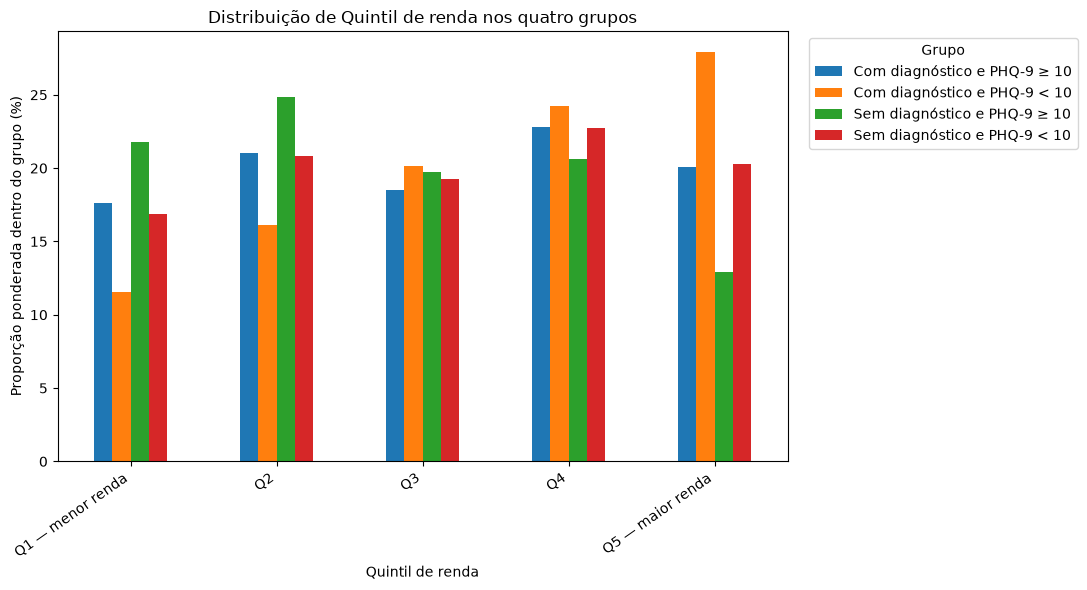

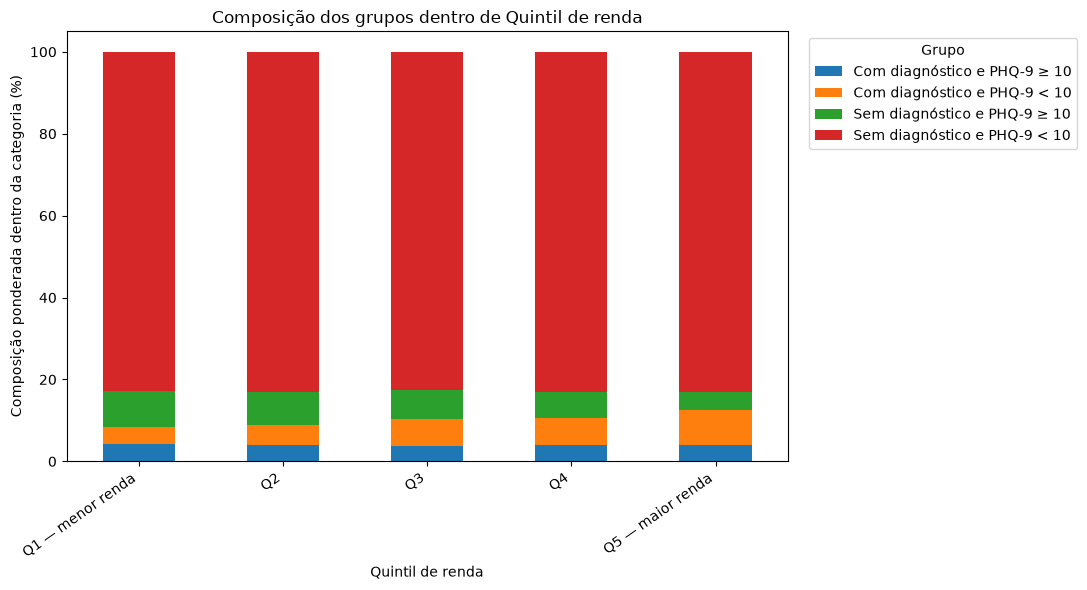

In [31]:
# Troque somente o nome abaixo.
variavel_escolhida = "Quintil de renda"

resultado_variavel_escolhida = (
    mostrar_comparacao_detalhada(
        variavel_escolhida
    )
)
